# Testing on up to 5 lines

This notebook trains a CNN to convert a 64×64 black-and-white raster image containing up to 5 lines vector coordinates.

It uses two stages:

1. **Coordinate pre-training**: the CNN first learns coordinates directly.
2. **Differentiable raster backpropagation**: the predicted vector is rasterised inside TensorFlow, then compared against the original raster image.

Run the notebook from top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Settings

Increase `VECTOR_EPOCHS` or `RASTER_EPOCHS` if you want more training cycles.

In [2]:
IMG_SIZE = 64

N_TRAIN = 5000
N_TEST = 1000

VECTOR_EPOCHS = 150
RASTER_EPOCHS = 200

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)

## Create synthetic training data

Each sample contains one black line on a white background.

The label is the vector form:

```text
[x1, y1, x2, y2]
```

All coordinates are normalised between 0 and 1.

In [3]:
MAX_LINES = 5
MIN_LINES = 1
CONFIDENCE_THRESHOLD = 0.5


def create_line_image(img_size=64, min_length=12, min_lines=1, max_lines=5):
    """
    Create one 64x64 raster image containing between min_lines and max_lines random black lines.

    Returns:
        image_array: shape (64, 64, 1)
        label: shape (MAX_LINES * 5,)

    Each line label is:
        [x1, y1, x2, y2, confidence]

    If a line exists:
        confidence = 1

    If a line does not exist:
        coordinates = 0
        confidence = 0
    """

    def random_line():
        while True:
            x1, y1 = np.random.randint(0, img_size, size=2)
            x2, y2 = np.random.randint(0, img_size, size=2)

            length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            if length >= min_length:
                return x1, y1, x2, y2

    number_of_lines = np.random.randint(min_lines, max_lines + 1)

    lines = []

    for _ in range(number_of_lines):
        lines.append(random_line())

    # Sort lines so the order is more consistent for training
    lines = sorted(
        lines,
        key=lambda line: (
            (line[0] + line[2]) / 2,
            (line[1] + line[3]) / 2
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for line in lines:
        x1, y1, x2, y2 = line

        draw.line((x1, y1, x2, y2), fill=0, width=1)

        label_values.extend([
            x1 / (img_size - 1),
            y1 / (img_size - 1),
            x2 / (img_size - 1),
            y2 / (img_size - 1),
            1.0
        ])

    # Fill unused line slots with zeros
    while len(label_values) < max_lines * 5:
        label_values.extend([
            0.0, 0.0, 0.0, 0.0, 0.0
        ])

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5000, 64, 64, 1)
y_train: (5000, 25)
X_test: (1000, 64, 64, 1)
y_test: (1000, 25)


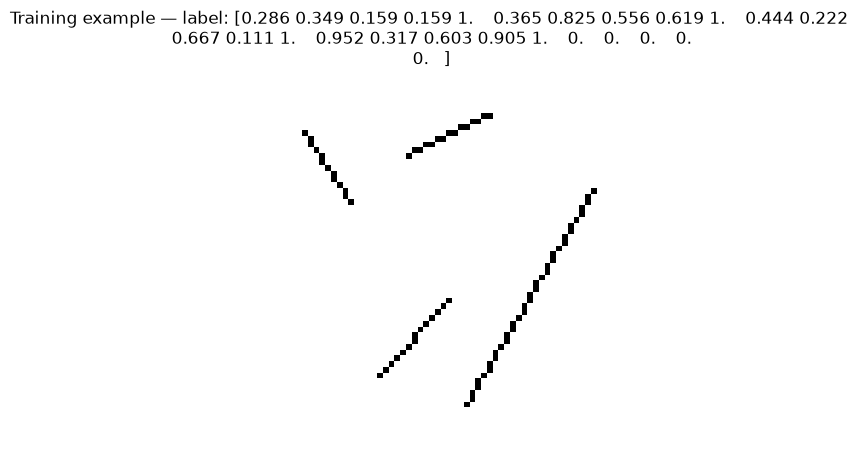

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()

## Build the CNN vector model

The CNN predicts four numbers:

```text
[x1, y1, x2, y2]
```

In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)

    vector_output = layers.Dense(MAX_LINES * 5, activation="sigmoid", name="vector_output")(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="vector_model")


vector_model = build_vector_model()
vector_model.summary()

Model: "vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vector_output (Dense)                │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,373,785 (9.06 MB)

 Trainable params: 2,373,785 (9.06 MB)

 Non-trainable params: 0 (0.00 B)

## Coordinate loss

A line is the same line if its endpoints are swapped, so this loss checks both endpoint orders and uses whichever is better.

In [7]:
def line_coordinate_loss(y_true, y_pred):
    """
    Loss for up to MAX_LINES predicted lines.

    Each line is:
        [x1, y1, x2, y2, confidence]

    Coordinate loss is only applied to real lines.
    Confidence loss is applied to all line slots.
    """

    y_true = tf.reshape(y_true, (-1, MAX_LINES, 5))
    y_pred = tf.reshape(y_pred, (-1, MAX_LINES, 5))

    true_coords = y_true[:, :, 0:4]
    pred_coords = y_pred[:, :, 0:4]

    true_conf = y_true[:, :, 4]
    pred_conf = y_pred[:, :, 4]

    # Direct endpoint order
    direct_loss = tf.reduce_mean(
        tf.square(true_coords - pred_coords),
        axis=-1
    )

    # Reversed endpoint order
    reversed_pred_coords = tf.stack([
        pred_coords[:, :, 2],
        pred_coords[:, :, 3],
        pred_coords[:, :, 0],
        pred_coords[:, :, 1]
    ], axis=-1)

    reversed_loss = tf.reduce_mean(
        tf.square(true_coords - reversed_pred_coords),
        axis=-1
    )

    # Use whichever endpoint direction is better
    coordinate_loss = tf.minimum(direct_loss, reversed_loss)

    # Only punish coordinate error for real lines
    coordinate_loss = coordinate_loss * true_conf

    number_of_real_lines = tf.reduce_sum(true_conf, axis=1) + 1e-8

    coordinate_loss = tf.reduce_sum(
        coordinate_loss,
        axis=1
    ) / number_of_real_lines

    # Confidence loss
    confidence_loss = tf.keras.backend.binary_crossentropy(
        true_conf,
        pred_conf
    )

    confidence_loss = tf.reduce_mean(confidence_loss, axis=1)

    total_loss = coordinate_loss + 0.2 * confidence_loss

    return tf.reduce_mean(total_loss)

## Stage 1 — train the CNN on vector coordinates first

This prevents the raster model from collapsing into a fuzzy dot.

In [8]:
vector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=line_coordinate_loss,
    metrics=["mae"]
)

history_vector = vector_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=VECTOR_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1025 - mae: 0.3435 - val_loss: 0.0723 - val_mae: 0.3377
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0656 - mae: 0.3296 - val_loss: 0.0599 - val_mae: 0.3390
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0537 - mae: 0.3300 - val_loss: 0.0560 - val_mae: 0.3374
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0462 - mae: 0.3274 - val_loss: 0.0526 - val_mae: 0.3318
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0411 - mae: 0.3236 - val_loss: 0.0557 - val_mae: 0.3342
Epoch 6/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0396 - mae: 0.3208 - val_loss: 0.0509 - val_mae: 0.3281
Epoch 7/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0356 - mae: 0.3172 - val_loss: 0.0542 - val_mae: 0.3318
Epoch 8/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0314 - mae: 0.3153 - val_loss: 0.0570 - val_mae: 0.3275
Epoch 9/150
157/157 ━━━━━━━━━━━━━━━━━━━━

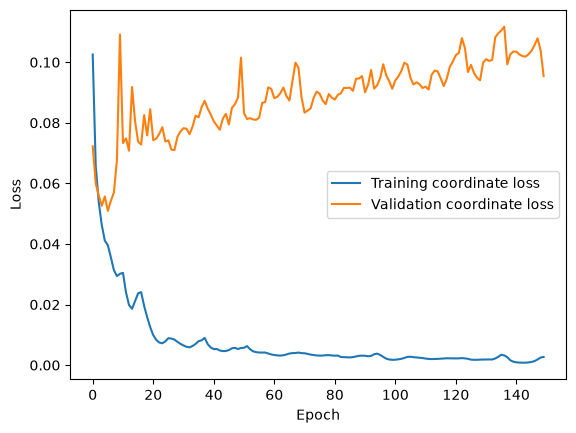

In [9]:
plt.plot(history_vector.history["loss"], label="Training coordinate loss")
plt.plot(history_vector.history["val_loss"], label="Validation coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Differentiable rasteriser

This layer converts predicted vector coordinates back into a soft raster image using TensorFlow maths.

Because it is TensorFlow-based, backpropagation can pass through it.

In [10]:
class DifferentiableLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.012, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, 1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, 1, img_size, img_size))

    def call(self, vectors):
        vectors = tf.reshape(vectors, (-1, MAX_LINES, 5))

        x1 = tf.reshape(vectors[:, :, 0], (-1, MAX_LINES, 1, 1))
        y1 = tf.reshape(vectors[:, :, 1], (-1, MAX_LINES, 1, 1))
        x2 = tf.reshape(vectors[:, :, 2], (-1, MAX_LINES, 1, 1))
        y2 = tf.reshape(vectors[:, :, 3], (-1, MAX_LINES, 1, 1))

        confidence = tf.reshape(vectors[:, :, 4], (-1, MAX_LINES, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(
            -distance_squared / (2.0 * self.sigma * self.sigma)
        )

        # Confidence controls whether each line appears
        line_darkness = line_darkness * confidence

        # Combine multiple lines
        combined_darkness = 1.0 - tf.reduce_prod(
            1.0 - line_darkness,
            axis=1
        )

        # Black line on white background
        raster = 1.0 - combined_darkness

        raster = tf.expand_dims(raster, axis=-1)

        return raster

## Weighted raster loss

Normal MSE performs badly because most pixels are white. This weighted loss gives black line pixels much more importance.

In [11]:
def weighted_raster_loss(y_true, y_pred):
    black_pixel_weight = 40.0
    weights = 1.0 + black_pixel_weight * (1.0 - y_true)
    loss = weights * tf.square(y_true - y_pred)
    return tf.reduce_mean(loss)

## Stage 2 — train through the differentiable rasteriser

This model has two losses:

1. Raster loss: predicted raster should match the input raster.
2. Coordinate loss: predicted vector should not drift away from the true vector.

The raster loss is the important Option B part.

In [12]:
raster_output = DifferentiableLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=[raster_output, vector_model.output],
    name="option_b_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=[weighted_raster_loss, line_coordinate_loss],
    loss_weights=[1.0, 0.2],
    metrics=[["mae"], ["mae"]]
)

history_raster = training_model.fit(
    X_train,
    [X_train, y_train],
    validation_data=(X_test, [X_test, y_test]),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 0.6458 - raster_output_loss: 0.6439 - raster_output_mae: 0.0510 - vector_output_loss: 0.0027 - vector_output_mae: 0.2750 - val_loss: 0.8423 - val_raster_output_loss: 0.8296 - val_raster_output_mae: 0.0536 - val_vector_output_loss: 0.0947 - val_vector_output_mae: 0.3111
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.5722 - raster_output_loss: 0.5705 - raster_output_mae: 0.0487 - vector_output_loss: 0.0019 - vector_output_mae: 0.2746 - val_loss: 0.8408 - val_raster_output_loss: 0.8282 - val_raster_output_mae: 0.0536 - val_vector_output_loss: 0.0942 - val_vector_output_mae: 0.3115
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.5175 - raster_output_loss: 0.5158 - raster_output_mae: 0.0464 - vector_output_loss: 0.0018 - vector_output_mae: 0.2747 - val_loss: 0.8398 - val_raster_output_loss: 0.8271 - val_raster_output_mae: 0.0537 - val_vector_output_loss: 0.0943 - val_vector_output_mae: 0.3119
Epo

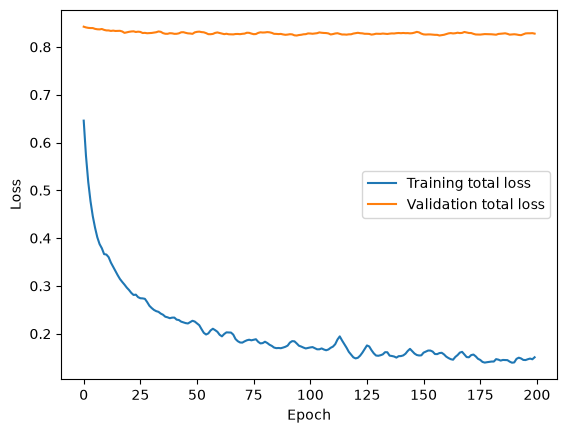

In [13]:
plt.plot(history_raster.history["loss"], label="Training total loss")
plt.plot(history_raster.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Test the trained model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Predicted lines:
Line 1: (17.6, 17.2) to (38.7, 53.5) confidence=1.00
Line 2: (28.4, 11.6) to (37.1, 56.8) confidence=1.00


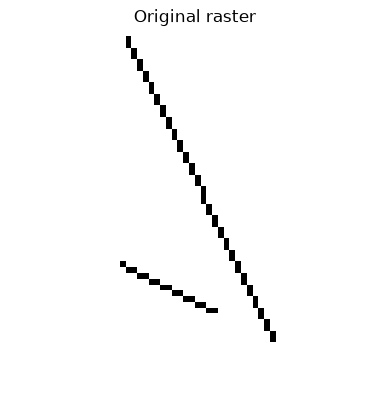

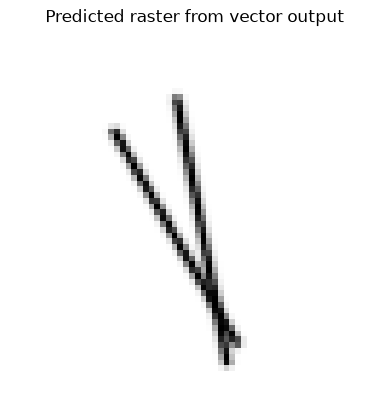

In [14]:
raster_model = models.Model(
    inputs=vector_model.input,
    outputs=raster_output,
    name="raster_prediction_model"
)

sample = X_test[0:1]

predicted_values = vector_model.predict(sample)[0]
predicted_raster = training_model.predict(sample)[0]

predicted_lines = predicted_values.reshape(MAX_LINES, 5)

print("Predicted lines:")

for i, line in enumerate(predicted_lines):
    x1, y1, x2, y2, confidence = line

    if confidence >= CONFIDENCE_THRESHOLD:
        print(
            f"Line {i + 1}: "
            f"({x1 * (IMG_SIZE - 1):.1f}, {y1 * (IMG_SIZE - 1):.1f}) "
            f"to "
            f"({x2 * (IMG_SIZE - 1):.1f}, {y2 * (IMG_SIZE - 1):.1f}) "
            f"confidence={confidence:.2f}"
        )

plt.imshow(sample.squeeze(), cmap="gray")
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray")
plt.title("Predicted raster from vector output")
plt.axis("off")
plt.show()

## Compare several predictions

Example 0
True pixels:      [19 40 35 48 63 20  1 45 53 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
Predicted pixels: [18 17 39 54 63 28 12 37 57 63 39 55 37 25  0 50 32 26 26  0 38 19 44 55
  0]


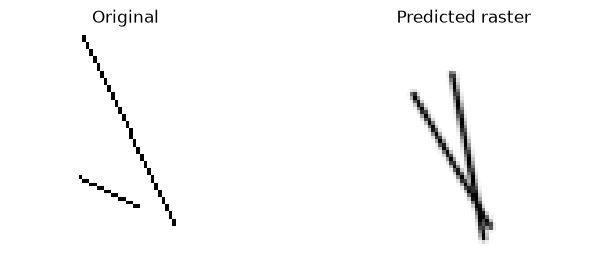

Example 1
True pixels:      [22 38 30  3 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
Predicted pixels: [29  3 21 41 63 27 24 53 21  0 44 18 36 39  0 55 10 18 33  0 33 41 45 24
  0]


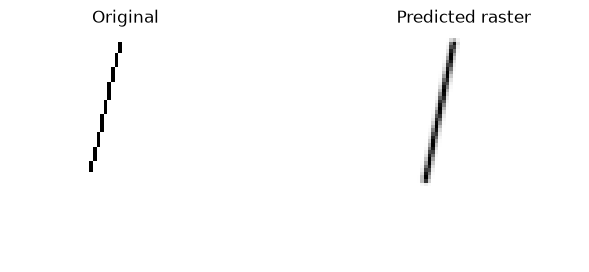

Example 2
True pixels:      [ 2 36 52 55 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
Predicted pixels: [54 55  4 35 63 18 35 56 41  0 18 48 37 41  0 33 17 16 36  0 22 22 32 29
  0]


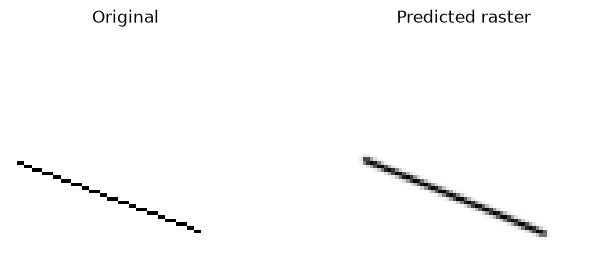

Example 3
True pixels:      [26 52 48 18 63 41 31 35 48 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
Predicted pixels: [35 27 29 52 63 33 46 45 27 63 47 28 26 53  5 35 23 36 41  0 52 41 34 38
  0]


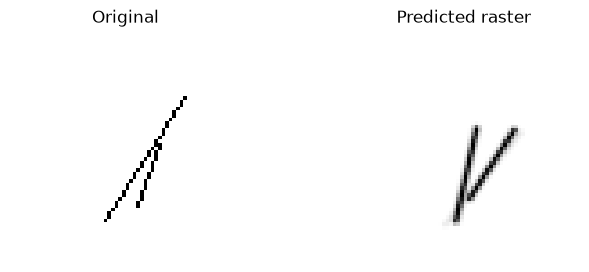

Example 4
True pixels:      [25 45 61 12 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
Predicted pixels: [60 13 21 45 63 30 40 61  7  0 59 19 34 54  0 40 10 39 40  0 54 41 22 42
  0]


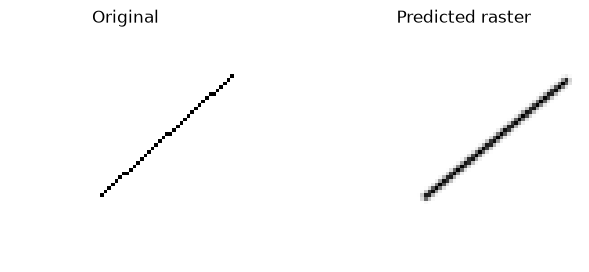

In [15]:
for sample_index in range(5):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]
    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_raster = raster_model.predict(sample, verbose=0)[0]

    print("Example", sample_index)
    print("True pixels:     ", np.round(true_vector * (IMG_SIZE - 1)).astype(int))
    print("Predicted pixels:", np.round(predicted_vector * (IMG_SIZE - 1)).astype(int))

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Predicted raster")
    plt.axis("off")

    plt.show()

In [ ]:
This is disapointing... It predicts a single line well, but struggles with multiple lines.

(≧﹏ ≦)

## Export the predicted line as SVG

In [18]:
def vector_to_svg(vector, img_size=64, confidence_threshold=0.5):
    """
    Converts model output into SVG.

    Expected vector shape:
        MAX_LINES * 5

    Each line:
        x1, y1, x2, y2, confidence
    """

    lines = vector.reshape(MAX_LINES, 5)

    svg_lines = []

    for line in lines:
        x1, y1, x2, y2, confidence = line

        if confidence >= confidence_threshold:
            x1 = int(round(x1 * (img_size - 1)))
            y1 = int(round(y1 * (img_size - 1)))
            x2 = int(round(x2 * (img_size - 1)))
            y2 = int(round(y2 * (img_size - 1)))

            svg_lines.append(
                f'  <line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
                f'stroke="black" stroke-width="1"/>'
            )

    svg = (
        f'<svg width="{img_size}" height="{img_size}" xmlns="http://www.w3.org/2000/svg">\n'
        f'  <rect width="100%" height="100%" fill="white"/>\n'
        + "\n".join(svg_lines) +
        f'\n</svg>'
    )

    return svg


svg_text = vector_to_svg(
    predicted_vector,
    IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

print(svg_text)

with open("predicted_lines.svg", "w") as f:
    f.write(svg_text)

print("Saved predicted_lines.svg")

<svg width="64" height="64" xmlns="http://www.w3.org/2000/svg">
  <rect width="100%" height="100%" fill="white"/>
  <line x1="60" y1="13" x2="21" y2="45" stroke="black" stroke-width="1"/>
</svg>
Saved predicted_lines.svg


## What to change next

To train for longer, edit these values near the top of the notebook:

```python
VECTOR_EPOCHS = 150
RASTER_EPOCHS = 200
```

If the line is still too blurry, try reducing:

```python
sigma=0.010
```

to:

```python
sigma=0.007
```

inside the `DifferentiableLineRasteriser(...)` call.